In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
from scipy.optimize import curve_fit

In [3]:
from math import pi

<img src='./viscosity/viscosity.png' width='50%'>

In [4]:
a=np.array([0.1279,0.1462])

In [5]:
f1={} # empty dictionary

for aa in a:
    f1[aa]=pd.read_csv(f'./viscosity/viscosity_a{aa}.csv')


In [6]:
f1[a[0]] #細管のデータ

,M,h1,h2
0,83.9600,558.5,151.0
1,77.8500,558.5,198.0
2,68.6100,558.5,251.0
3,59.3050,558.5,300.5
4,49.8000,558.5,352.0
5,40.5650,558.5,400.0
6,29.5050,558.5,451.0
7,24.2200,558.5,471.0
8,18.2850,558.5,492.0
9,16.4150,558.5,500.0


In [7]:
f1[a[1]] #太管のデータ

,M,h1,h2
0,111.5800,558.5,150
1,107.3200,558.5,200
2,96.8800,558.5,250
3,85.9700,558.0,300
4,73.6600,558.5,350
5,59.5450,558.5,400
6,44.7900,558.5,451
7,37.9500,558.5,470
8,31.0150,558.5,490
9,26.1800,559.0,502


v0=1/(pi*a^2*t)

v=v0/rho

eta=pi*a^4*rho*g*t/(8*l)

In [8]:
t=15
l=38.0
g=9.8

aa=a[0]
m=f1[aa]['M']
v0=1/(pi*aa**2*t)
v=v0*m
h1=f1[aa]['h1']/10
h2=f1[aa]['h2']/10
h=h1-h2

eta0=10**4*pi*g*aa**4*t/(8*l)
eta=eta0*(h/m)

f1[aa]['h']=h
f1[aa]['v']=v
f1[aa]['eta']=eta

In [9]:
h

0     40.75
1     36.05
2     30.75
3     25.80
4     20.65
5     15.85
6     10.75
7      8.75
8      6.65
9      5.85
10     4.75
11     3.80
12     2.85
13     1.90
dtype: float64

In [10]:
v

0     108.915630
1     100.989541
2      89.003113
3      76.932366
4      64.602172
5      52.622231
6      38.274841
7      31.418968
8      23.719894
9      21.294069
10     16.896452
11     13.948491
12      9.943286
13      5.772684
Name: M, dtype: float64

In [11]:
eta

0     1.973018
1     1.882446
2     1.821938
3     1.768496
4     1.685647
5     1.588377
6     1.481115
7     1.468621
8     1.478436
9     1.448741
10    1.482490
11    1.436647
12    1.511501
13    1.735679
dtype: float64

In [12]:
t=15
l=38.0
g=9.8

aa=a[1]
m=f1[aa]['M']
v0=1/(pi*aa**2*t)
V=v0*m
h1=f1[aa]['h1']/10
h2=f1[aa]['h2']/10
H=h1-h2

eta0=10**4*pi*g*aa**4*t/(8*l)
Eta=eta0*(h/m)

f1[aa]['h']=H
f1[aa]['v']=V
f1[aa]['eta']=Eta

In [13]:
H

0     40.85
1     35.85
2     30.85
3     25.80
4     20.85
5     15.85
6     10.75
7      8.85
8      6.85
9      5.70
10     4.70
11     3.60
12     2.70
13     1.60
dtype: float64

In [14]:
V

0     110.777225
1     106.547874
2      96.182985
3      85.351479
4      73.130044
5      59.116596
6      44.467753
7      37.676964
8      30.791859
9      25.991645
10     21.295675
11     15.706181
12     11.725032
13      5.755789
Name: M, dtype: float64

In [15]:
Eta

0     2.534687
1     2.331351
2     2.202897
3     2.082840
4     1.945680
5     1.847426
6     1.665753
7     1.600219
8     1.488103
9     1.550848
10    1.536914
11    1.667095
12    1.674858
13    2.274552
dtype: float64

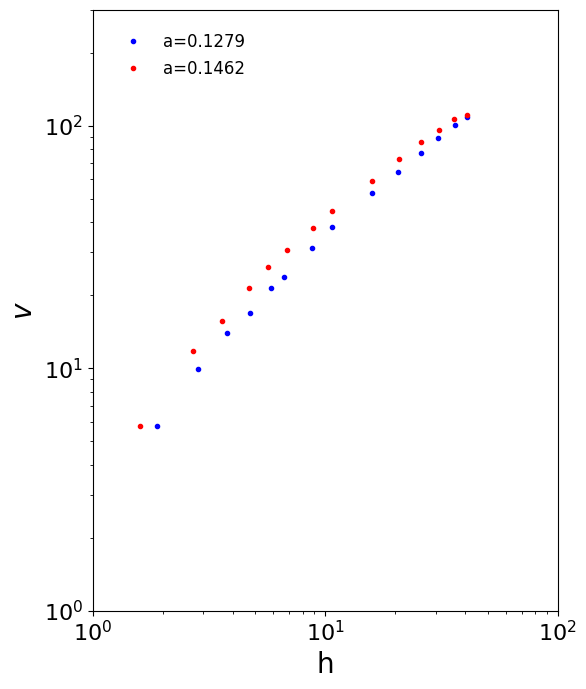

In [16]:
r=6
fig=plt.figure(figsize=(r*1,r*1.3))

plt.xlabel('h',fontsize=20)
plt.ylabel('$v$',fontsize=20)
plt.xscale('log')
plt.yscale('log')


plt.xlim(1,100)
plt.ylim(1,300)
plt.tick_params(labelsize=16)

a0=a[0]
h=f1[a0]['h']
v=f1[a0]['v']
plt.plot(h,v,'b.',label=f'a={a0}')


a0=a[1]
h=f1[a0]['h']
v=f1[a0]['v']
plt.plot(h,v,'r.',label=f'a={a0}')

legend=plt.legend(bbox_to_anchor=(0.0,1.0), loc='upper left', borderaxespad=1, fontsize=12, ncol=1)
frame = legend.get_frame()
frame.set_linewidth(0)

plt.show()

## 乱流転移の臨界速度を推定する

In [17]:
def func(x, a, b):
    return a*10**(b*np.log10(x))

### 臨界点より上の速度の高度依存性をフィットする

In [18]:
h=f1[a[1]]['h']
v=f1[a[1]]['v']
h[:6] #0始まりで6個の値. フィットする範囲はデータの定性的な振る舞いから判断した。

0    40.85
1    35.85
2    30.85
3    25.80
4    20.85
5    15.85
Name: h, dtype: float64

In [19]:
#ここでは使わないがもし逆順にソートし直したい場合は次のようにする
h[:6][::-1] #0始まりで6個の値

5    15.85
4    20.85
3    25.80
2    30.85
1    35.85
0    40.85
Name: h, dtype: float64

In [20]:
popt, pcov = curve_fit(func, h[:6],v[:6])

In [21]:
popt[0],np.sqrt(pcov[0,0])

(9.94935492341694, 1.2517851533019348)

### 臨界点より下の速度の高度依存性をフィットする

In [22]:
h[7:-1]

7     8.85
8     6.85
9     5.70
10    4.70
11    3.60
12    2.70
Name: h, dtype: float64

In [23]:
popt2, pcov2 = curve_fit(func, h[7:-1],v[7:-1])

In [24]:
popt2[0],np.sqrt(pcov2[0,0])

(4.78639485359553, 0.3499518924007971)

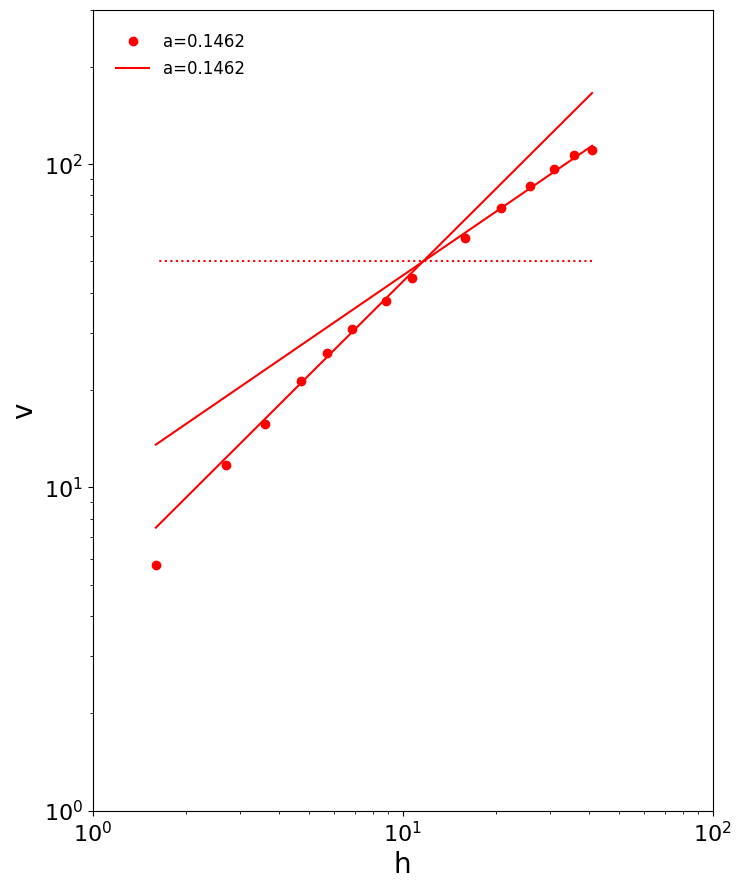

In [25]:
r=8
fig=plt.figure(figsize=(r*1,r*1.3))

plt.xlabel('h',fontsize=20)
plt.ylabel('v',fontsize=20)
plt.xscale('log')
plt.yscale('log')


plt.xlim(1,100)
plt.ylim(1,300)
plt.tick_params(labelsize=16)

a0=a[1]
h=f1[a0]['h']
v=f1[a0]['v']
label=f'a={a0}'

plt.plot(h,v,'ro',label=label)
plt.plot(h,50*np.ones(len(v)),'r:')
plt.plot(h,func(h,*popt),'r-',label=label)
plt.plot(h,func(h,*popt2),'r-')

legend=plt.legend(bbox_to_anchor=(0.0,1.0), loc='upper left', borderaxespad=1, fontsize=12, ncol=1)
frame = legend.get_frame()
frame.set_linewidth(0)

plt.show()

# 問　同様にして細管の臨界速度を推定し、推定結果をプロットせよ. また、結果から臨界速度を推定せよ.

In [ ]:
### ここにグラフを描くコードを追加
















# 粘性をプロットする

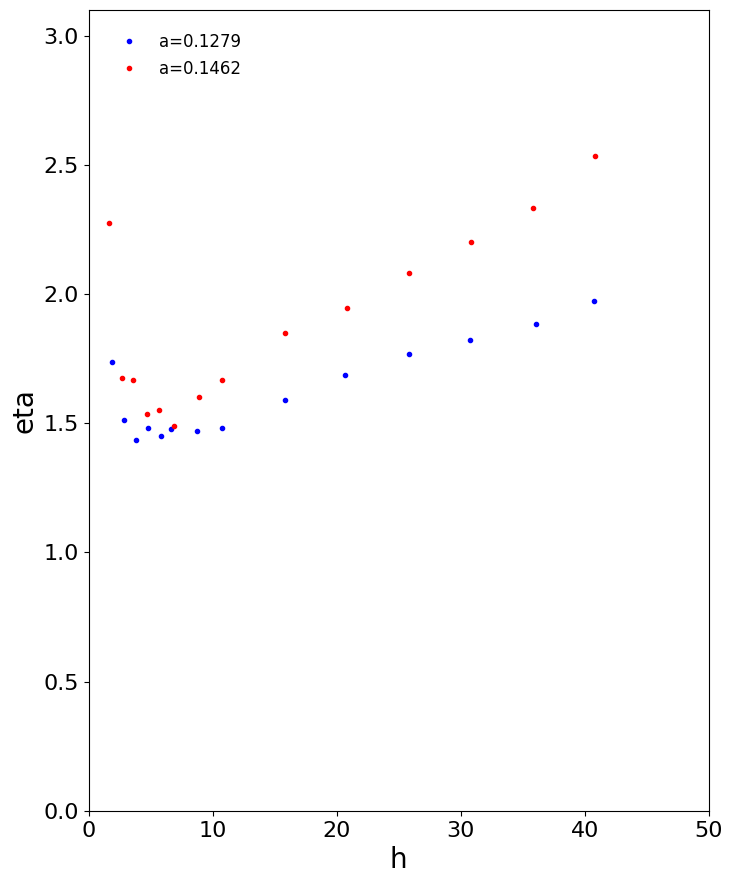

In [26]:
r=8
fig=plt.figure(figsize=(r*1,r*1.3))
plt.xlabel('h',fontsize=20)
plt.ylabel('eta',fontsize=20)
#plt.xscale('log')
#plt.yscale('log')


plt.xlim(0,50)
plt.ylim(0,3.1)
plt.tick_params(labelsize=16)

h=f1[a[0]]['h']
eta=f1[a[0]]['eta']
plt.plot(h,eta,'b.',label=f'a={a[0]}')

h=f1[a[1]]['h']
eta=f1[a[1]]['eta']
plt.plot(h,eta,'r.',label=f'a={a[1]}')

legend=plt.legend(bbox_to_anchor=(0.0,1.0), loc='upper left', borderaxespad=1, fontsize=12, ncol=1)
frame = legend.get_frame()
frame.set_linewidth(0)

plt.show()

In [27]:
def func(x, a, b):
    return a*x+b

In [28]:
h=f1[a[1]]['h']
eta=f1[a[1]]['eta']
popt, pcov = curve_fit(func, h[4:7],eta[4:7])

In [29]:
popt[1],np.sqrt(pcov[1,1])

(1.380834507599503, 0.0753511320542282)

# eta= 1.23 mPas at T=12 C, 1.27 mPas at T=11 C

## 問　同様に太管の粘性を推定せよ. 

In [ ]:
## ここに最小二乗法のコードを追加












